# Capstone Project
## Image classifier for the SVHN dataset

In this notebook, a neural network was implemented to classifies real-world images digits. This project utilized the conventional techniques employed in deep learning which are building, training, testing, validating and saving the Tensorflow classifier model, an end-to-end workflow that classifies a real-world image into a class.

Also, this project implemented a neural network using Multilayer Perceptron and Convolutional Network as a way to compare and contrast  the performance of these models when it involves applying them for image classification task.

The [SVHN dataset](http://ufldl.stanford.edu/housenumbers/) was used for this image classification task. This is an  image dataset of over 600,000 digit images in all and is a harder dataset than MNIST as the numbers appear in the context of natural scene images. SVHN is obtained from house numbers in Google Street View images and each image in the dataset is assigned to one of the ten classes which are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9. 

* Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu and A. Y. Ng. "Reading Digits in Natural Images with Unsupervised Feature Learning". NIPS Workshop on Deep Learning and Unsupervised Feature Learning, 2011.

In [65]:
import os
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

%matplotlib inline

Both `train` and `test` are dictionaries with keys `X` and `y` for the input images and labels respectively.

In [5]:
# Run this cell to load the dataset

train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')

## Inspect and preprocess the dataset
* Extract the train and test images and labels separately from the loaded train and test dictionaries respectively.
* Select a random sample of images and corresponding labels from the dataset (at least 10), and display them in a figure.
* Convert the train and test images to grayscale by taking the average across all colour channels for each pixel.
* Select a random sample of the grayscale images and corresponding labels from the dataset (at least 10) and display them in a figure.

In [6]:
train_images = train["X"]
train_labels = train["y"]
test_images = test["X"]
test_labels = test["y"]

In [7]:
print("shape of the train images", train_images.shape)
print("shape of the test images", test_images.shape)

shape of the train images (32, 32, 3, 73257)
shape of the test images (32, 32, 3, 26032)


In [8]:
def display_images(digit):
    digit_labels = train_labels[train_labels == digit]
    if len(digit_labels) != 0:
        digit_labels_idxs = np.where(np.isin(train_labels, digit_labels))[0]
        random_digit_images_idxs = np.random.choice(digit_labels_idxs, size=15, replace=False)
        figure, axs = plt.subplots(3, 5)
        
        for idx, ax in zip(random_digit_images_idxs, axs.flat):
            ax.imshow(train_images[:, :, :, idx])
            ax.set_title(train_labels[idx])
            ax.axis("off")
            
        figure.tight_layout()
    
    else:
        return f"{digit} not in the labels"

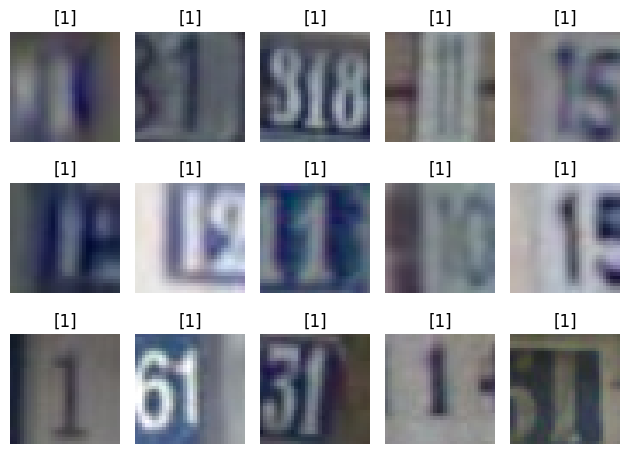

In [9]:
display_images(1)

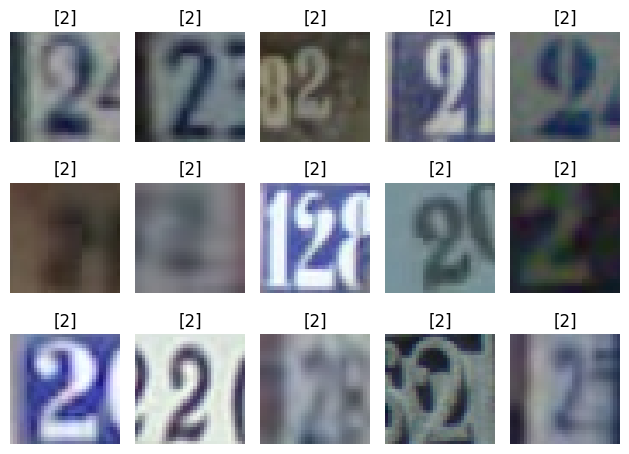

In [10]:
display_images(2)

In [11]:
display_images(0)

'0 not in the labels'

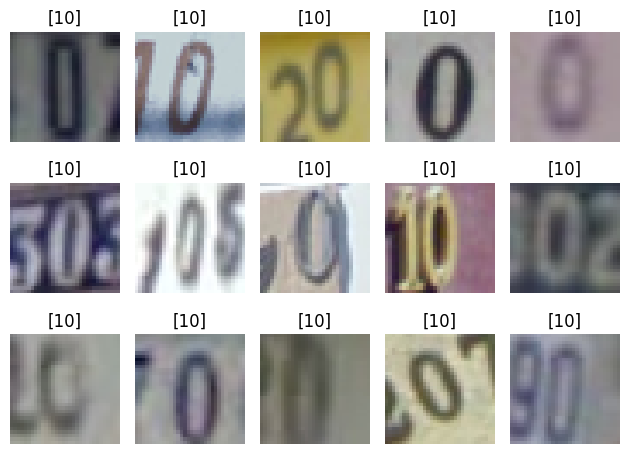

In [12]:
display_images(10)

There are 10 class labels in the dataset labelled 1, 2, 3, 4, 5, 6, 7, 8, 10, which is a softmax output but clearly shows that 0 is absent. \
However this vector will throw up an error while compiling the model because softmax output only range between 0 - 9 using either categorial or sparse cross entropy.\
So, a preprocessing step is performed by changing the 10 (class label) to 0.

In [13]:
train_labels = np.where(train_labels == 10, 0, train_labels)
test_labels = np.where(test_labels == 10, 0, test_labels)

In [14]:
display_images(10)

'10 not in the labels'

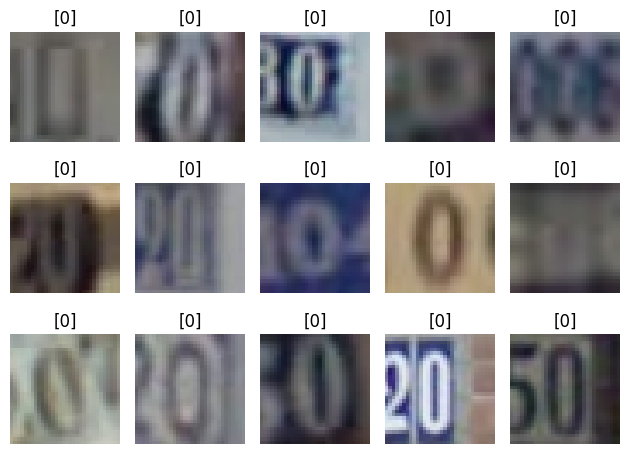

In [15]:
display_images(0)

In [16]:
distinct_labels = np.unique(train_labels)
distinct_labels

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

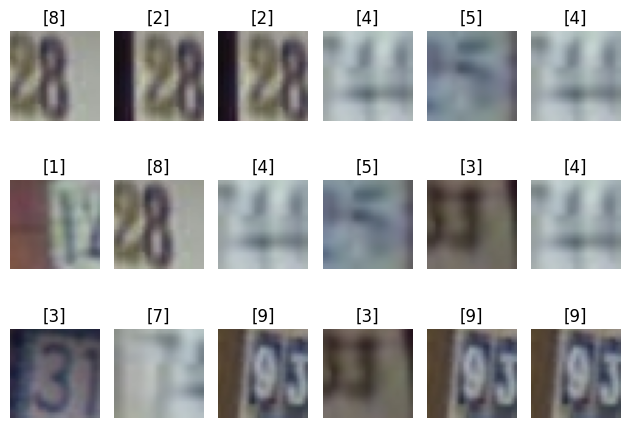

In [17]:
random_imgs = np.random.choice(18, train_images.shape[-1])
fig, ax1 = plt.subplots(3, 6)
for idx, ax in zip(random_imgs, ax1.flat):
    img = train_images[:, :, :, idx]
    label = train_labels[idx]
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

fig.tight_layout()

In [18]:
train_images_gray = train_images.mean(axis=2, keepdims=True)
test_images_gray = test_images.mean(axis=2, keepdims=True)

In [19]:
print("shape of the grayscale train images", train_images_gray.shape)
print("shape of the grayscale test images", test_images_gray.shape)

shape of the grayscale train images (32, 32, 1, 73257)
shape of the grayscale test images (32, 32, 1, 26032)


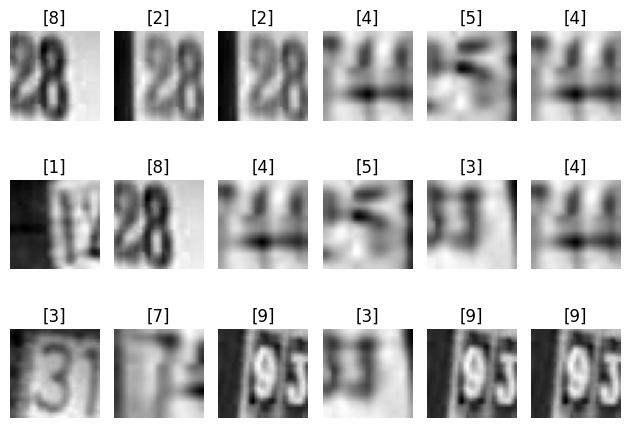

In [20]:
fig2, ax2 = plt.subplots(3, 6)
for idx, ax in zip(random_imgs, ax2.flat):
    img = train_images_gray[:, :, :, idx].reshape(32, 32)
    label = train_labels[idx]
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis('off')

fig2.tight_layout()

## MLP neural network classifier
* Build an MLP classifier model using the Sequential API. The model use only Flatten and Dense layers, with the final layer having a 10-way softmax output.
* Print out the model summary (using the summary() method)
* Compile and train the model over a maximum of 30 epochs, making use of both train and validation sets during the training. 
* The model track at least one appropriate metric and use at least two callbacks during training, one of which was a ModelCheckpoint callback.
* Achieve a final categorical cross entropy training loss of less than 1.0 (the validation loss might be higher).
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both train and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [21]:
train_images_transpose = train_images_gray.transpose(3, 0, 1, 2)
test_images_transpose = test_images_gray.transpose(3, 0, 1, 2)

In [22]:
from tensorflow.keras.utils import to_categorical

In [23]:
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)

In [31]:
def create_mlp():
    mlp = keras.models.Sequential(
        [keras.Input((32, 32, 1)), # input layer
         keras.layers.Flatten(),   # flattening the input layers
         keras.layers.Dense(250, activation="relu"),  # first hidden layer
         keras.layers.Dense(150, activation="relu"),  # second hidden layer
         keras.layers.Dense(100, activation="relu"),  # third hidden layer
         keras.layers.Dense(10, activation="softmax") # output layer, softmax
        ]
    )
    
    mlp.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return mlp

In [32]:
mlp = create_mlp()
mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 250)            │       256,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 150)            │        37,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,010 (1.18 MB)

 Trainable params: 310,010 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [34]:
def model_checkpoint(dir_path):
    model_checkpoint = ModelCheckpoint(dir_path,
                                       save_weights_only=True,
                                       save_best_only=True,
                                       monitor="loss",
                                       verbose=1
                                      )
    return model_checkpoint

def early_stopping():
    earlystop_check = EarlyStopping(monitor="loss", patience=3, verbose=1)
    return earlystop_check

In [36]:
mlp_dir_path = "checkpoint_mlp"
model_checkpoint_mlp = model_checkpoint(mlp_dir_path + "/best_mlp.weights.h5")
early_stopping_mlp = early_stopping()

In [37]:
mlp_history = mlp.fit(train_images_transpose,
                      encoded_train_labels,
                      validation_data=(test_images_transpose, encoded_test_labels),
                      callbacks=[model_checkpoint_mlp, early_stopping_mlp],
                      epochs=30,
                      verbose=1
                     )

Epoch 1/30
2284/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1816 - loss: 9.8520
Epoch 1: loss improved from None to 3.76226, saving model to checkpoint_mlp/best_mlp.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2734 - loss: 3.7623 - val_accuracy: 0.3448 - val_loss: 2.0924
Epoch 2/30
2288/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4715 - loss: 1.6193
Epoch 2: loss improved from 3.76226 to 1.55132, saving model to checkpoint_mlp/best_mlp.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4953 - loss: 1.5513 - val_accuracy: 0.4099 - val_loss: 2.1777
Epoch 3/30
2285/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5446 - loss: 1.4270
Epoch 3: loss improved from 1.55132 to 1.37497, saving model to checkpoint_mlp/best_mlp.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5598 - loss: 1.3750 - val_accuracy: 0.6013 - val_loss: 1.2935
Epoch 4/30
2283/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5981 - loss: 1

In [38]:
train_loss = mlp_history.history["loss"]
train_acc = mlp_history.history["accuracy"]
val_loss = mlp_history.history["val_loss"]
val_acc = mlp_history.history["val_accuracy"]

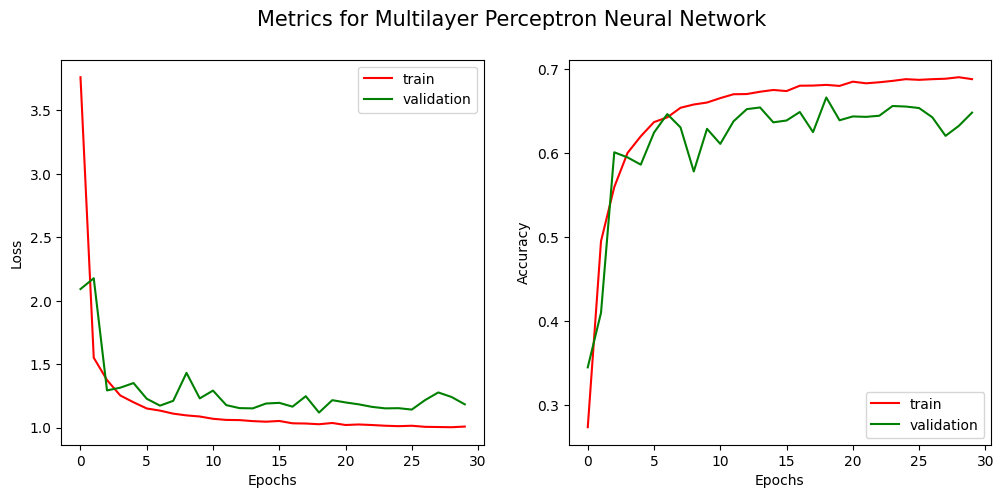

In [39]:
fig, (loss_ax, acc_ax) = plt.subplots(1, 2, figsize=[12, 5])
loss_ax.plot(train_loss, label="train", color="red")
loss_ax.plot(val_loss, label="validation", color="green")
loss_ax.set(xlabel="Epochs", ylabel="Loss")
loss_ax.legend()

acc_ax.plot(train_acc, label="train", color="red")
acc_ax.plot(val_acc, label="validation", color="green")
acc_ax.set(xlabel="Epochs", ylabel="Accuracy")
acc_ax.legend()

fig.suptitle("Metrics for Multilayer Perceptron Neural Network", fontsize=15)
fig.savefig("MLP_metrics.png");

In [40]:
mlp_loss, mlp_acc = mlp.evaluate(test_images_transpose, encoded_test_labels, verbose=0)
print(f"The MLP NN had a loss {mlp_loss:.4f} with {mlp_acc:%} accuracy")

The MLP NN had a loss 1.1838 with 64.858633% accuracy


## CNN neural network classifier
* Build a Convolutional Neural Network (CNN) classifier model using the Sequential API. The model uses the Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense and Dropout layers. The final layer again have a 10-way softmax output.
* The CNN model have fewer trainable parameters than the MLP model.
* Compile and train the model through 30 epochs, making use of both train and validation sets during the training run.
* The CNN model track at least one appropriate metric and use at least two callbacks during training, one of which should be a ModelCheckpoint callback.
* Aim to beat the MLP model performance with fewer parameters!
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both training and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [41]:
def create_convolutional_model():
    conv_model = keras.models.Sequential(
        [keras.layers.Input((32, 32, 1)),
         
         keras.layers.BatchNormalization(),
         keras.layers.Conv2D(16, (4, 4), activation="relu", padding="same"),
         keras.layers.MaxPooling2D(2, 2),
         
         keras.layers.BatchNormalization(),
         keras.layers.Conv2D(8, (4, 4), activation="relu", padding="same"),
         keras.layers.MaxPooling2D(2, 2),
         
         keras.layers.Flatten(),
         
         keras.layers.Dense(16, activation="relu"),
         keras.layers.Dense(10, activation="softmax")
        ]
    )
    
    conv_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return conv_model

In [42]:
conv_model = create_convolutional_model()
conv_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 32, 32, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 8)      │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,774 (42.09 KB)

 Trainable params: 10,740 (41.95 KB)

 Non-trainable params: 34 (136.00 B)

In [44]:
cnn_dir_path = "checkpoint_cnn"
model_checkpoint_conv = model_checkpoint(cnn_dir_path+"/best_cnn.weights.h5")
early_stopping_conv = early_stopping()

In [45]:
conv_history = conv_model.fit(train_images_transpose,
                              encoded_train_labels,
                              validation_data=(test_images_transpose, encoded_test_labels),
                              callbacks=[model_checkpoint_conv, early_stopping_conv],
                              epochs=30,
                              verbose=1
                             )

Epoch 1/30
2289/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4408 - loss: 1.6009
Epoch 1: loss improved from None to 1.15304, saving model to checkpoint_cnn/best_cnn.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 67s 28ms/step - accuracy: 0.6127 - loss: 1.1530 - val_accuracy: 0.7730 - val_loss: 0.7564
Epoch 2/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7977 - loss: 0.6624
Epoch 2: loss improved from 1.15304 to 0.63561, saving model to checkpoint_cnn/best_cnn.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 63s 28ms/step - accuracy: 0.8063 - loss: 0.6356 - val_accuracy: 0.8087 - val_loss: 0.6565
Epoch 3/30
2288/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8244 - loss: 0.5764
Epoch 3: loss improved from 0.63561 to 0.56887, saving model to checkpoint_cnn/best_cnn.weights.h5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 62s 27ms/step - accuracy: 0.8281 - loss: 0.5689 - val_accuracy: 0.8133 - val_loss: 0.6359
Epoch 4/30
2288/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8394 - 

In [47]:
cnn_train_loss = conv_history.history["loss"]
cnn_train_acc = conv_history.history["accuracy"]
cnn_val_loss = conv_history.history["val_loss"]
cnn_val_acc = conv_history.history["val_accuracy"]

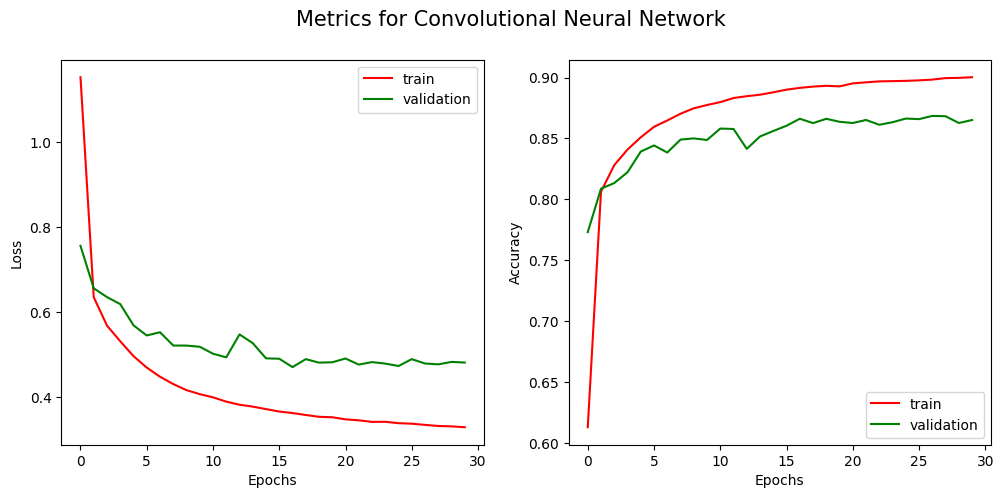

In [48]:
fig, (cnn_loss_ax, cnn_acc_ax) = plt.subplots(1, 2, figsize=[12, 5])
cnn_loss_ax.plot(cnn_train_loss, label="train", color="red")
cnn_loss_ax.plot(cnn_val_loss, label="validation", color="green")
cnn_loss_ax.set(xlabel="Epochs", ylabel="Loss")
cnn_loss_ax.legend()

cnn_acc_ax.plot(cnn_train_acc, label="train", color="red")
cnn_acc_ax.plot(cnn_val_acc, label="validation", color="green")
cnn_acc_ax.set(xlabel="Epochs", ylabel="Accuracy")
cnn_acc_ax.legend()

fig.suptitle("Metrics for Convolutional Neural Network", fontsize=15)
fig.savefig("CNN_metrics");

In [49]:
cnn_loss, cnn_acc = conv_model.evaluate(test_images_transpose, encoded_test_labels, verbose=0)
print(f"The CNN had a loss {cnn_loss:.4f} with {cnn_acc:%} accuracy")

The CNN had a loss 0.4819 with 86.512756% accuracy


## Get model predictions
* Load the best weights for the MLP and CNN models saved during the training run.
* Randomly select 5 images and corresponding labels from the test set and display the images with their labels.
* Alongside the image and label, show each model’s predictive distribution as a bar chart and the final model prediction given by the label with maximum probability.

In [67]:
#mlp_best_weights = tf.train.latest_checkpoint(mlp_dir_path)
#cnn_best_weights = tf.train.latest_checkpoint(cnn_dir_path)


new_mlp = create_mlp()
new_conv = create_convolutional_model()

new_mlp.load_weights(os.path.join("checkpoint_mlp", os.listdir(mlp_dir_path)[0]))
new_conv.load_weights(os.path.join("checkpoint_cnn", os.listdir(cnn_dir_path)[0]))

In [68]:
random_idx = np.random.choice(test_images_transpose.shape[0], 5)
random_test_images = test_images_transpose[random_idx]
random_test_labels = test_labels[random_idx]

mlp_predicts = new_mlp.predict(random_test_images)
cnn_predicts = new_conv.predict(random_test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


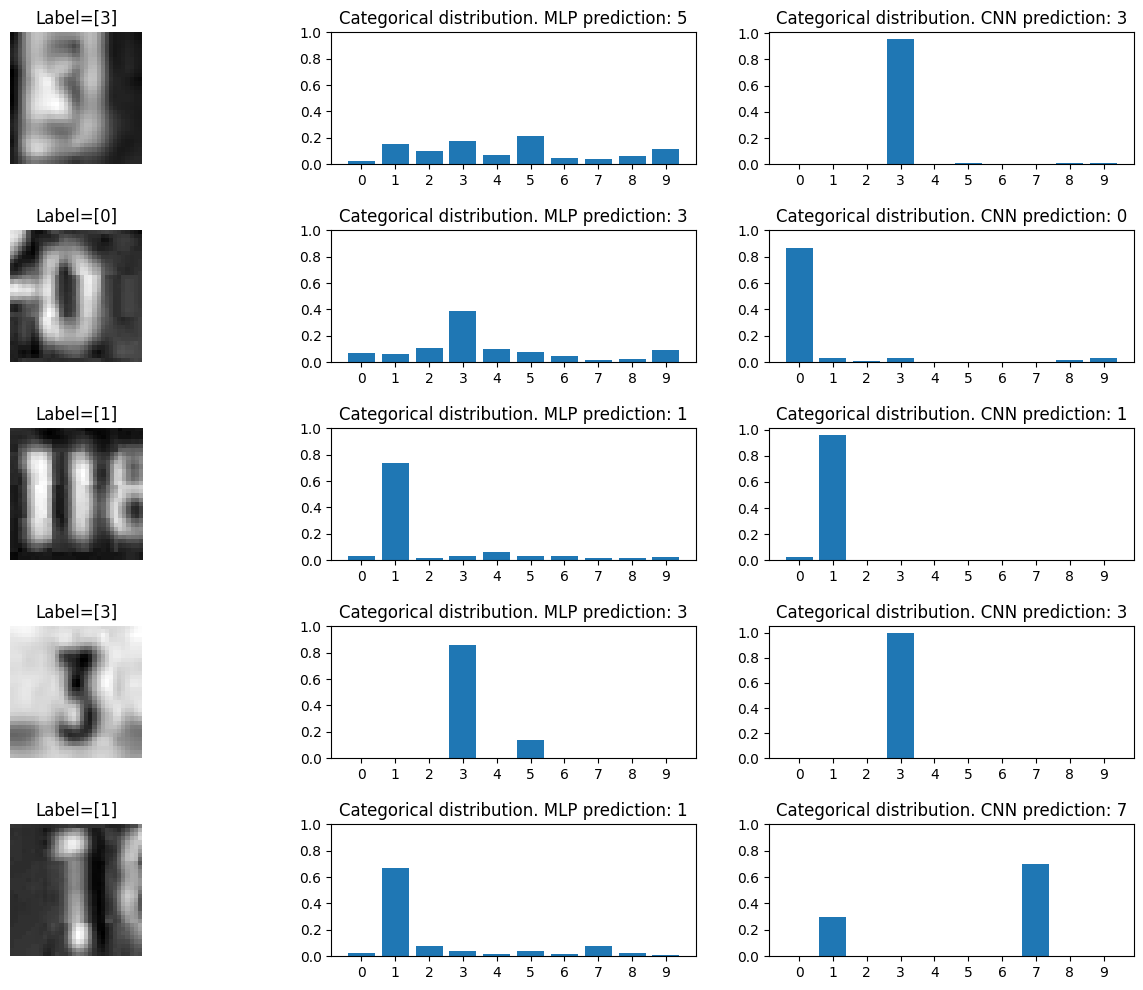

In [69]:
fig, axs = plt.subplots(5, 3, figsize=[16, 12])
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i in range(len(random_idx)):
    axs[i, 0].imshow(random_test_images[i].reshape(32, 32), cmap="gray")
    axs[i, 0].set_title("Label={}".format(random_test_labels[i]))
    axs[i, 0].axis('off')
    axs[i, 1].bar(np.arange(len(mlp_predicts[i])), mlp_predicts[i])
    axs[i, 1].set_title(f"Categorical distribution. MLP prediction: {np.argmax(mlp_predicts[i])}")
    axs[i, 1].set_xticks(np.arange(10))
    axs[i, 1].set_yticks(np.arange(0.0, 1.2, 0.2))
    axs[i, 2].bar(np.arange(len(cnn_predicts[i])), cnn_predicts[i])
    axs[i, 2].set_xticks(np.arange(10))
    axs[i, 2].set_yticks(np.arange(0.0, 1.2, 0.2))
    axs[i, 2].set_title(f"Categorical distribution. CNN prediction: {np.argmax(cnn_predicts[i])}")